# 딥러닝 라이브러리 2가지
## 텐서플로우(google) - 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
* 순차적, 함수적, 클래스

## 파이토치(meta) - 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [3]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']]

In [5]:
data.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C


In [6]:
data['family'] = data["SibSp"] + data['Parch']
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,family
0,0,3,male,22.0,1,0,S,1
1,1,1,female,38.0,1,0,C,1
2,1,3,female,26.0,0,0,S,0
3,1,1,female,35.0,1,0,S,1
4,0,3,male,35.0,0,0,S,0
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,S,0
887,1,1,female,19.0,0,0,S,0
888,0,3,female,NaN,1,2,S,3
889,1,1,male,26.0,0,0,C,0


In [7]:
data['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [8]:
data.loc[:, 'Age'] = data['Age'].fillna(data['Age'].mean())
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,family
0,0,3,male,22.000000,1,0,S,1
1,1,1,female,38.000000,1,0,C,1
2,1,3,female,26.000000,0,0,S,0
3,1,1,female,35.000000,1,0,S,1
4,0,3,male,35.000000,0,0,S,0
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,S,0
887,1,1,female,19.000000,0,0,S,0
888,0,3,female,29.699118,1,2,S,3
889,1,1,male,26.000000,0,0,C,0


In [9]:
data['Embarked'].mode()[0]

'S'

In [10]:
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  891 non-null    object 
 7   family    891 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 55.8+ KB


In [12]:
data = data.drop(['SibSp', 'Parch'], axis=1)
data

,Survived,Pclass,Sex,Age,Embarked,family
0,0,3,male,22.000000,S,1
1,1,1,female,38.000000,C,1
2,1,3,female,26.000000,S,0
3,1,1,female,35.000000,S,1
4,0,3,male,35.000000,S,0
...,...,...,...,...,...,...
886,0,2,male,27.000000,S,0
887,1,1,female,19.000000,S,0
888,0,3,female,29.699118,S,3
889,1,1,male,26.000000,C,0


In [13]:
data = pd.get_dummies(data, drop_first=True)
data

,Survived,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,True,False,True
1,1,1,38.000000,1,False,False,False
2,1,3,26.000000,0,False,False,True
3,1,1,35.000000,1,False,False,True
4,0,3,35.000000,0,True,False,True
...,...,...,...,...,...,...,...
886,0,2,27.000000,0,True,False,True
887,1,1,19.000000,0,False,False,True
888,0,3,29.699118,3,False,False,True
889,1,1,26.000000,0,True,False,False


In [14]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 딥러닝시에도 데이터의 스케일을 맞춰 주는것이 좋다.
* StandardScaler, MinMaxScaler를 주로 사용, 이상값이 많을 경우 RobustScaler를 사용
* 이진분류(0,1): MinMaxScaler
* 연속값예측: StandardScaler

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
mms = MinMaxScaler()
mms_X_train = mms.fit_transform(X_train)
mms_X_test = mms.transform(X_test)
mms_X_train = pd.DataFrame(mms_X_train, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(mms_X_test, columns=X_test.columns, index=X_test.index)
display(mms_X_train)
display(mms_X_test)

,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
748,0.0,0.233476,0.1,1.0,0.0,1.0
45,1.0,0.367921,0.0,1.0,0.0,1.0
28,1.0,0.367921,0.0,0.0,1.0,0.0
633,0.0,0.367921,0.0,1.0,0.0,1.0
403,1.0,0.346569,0.1,1.0,0.0,1.0
...,...,...,...,...,...,...
476,0.5,0.421965,0.1,1.0,0.0,1.0
190,0.5,0.396833,0.0,0.0,0.0,1.0
736,1.0,0.597889,0.4,0.0,0.0,1.0
462,0.0,0.585323,0.0,1.0,0.0,1.0


,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
625,0.0,0.761247,0.0,1.0,0.0,1.0
566,1.0,0.233476,0.0,1.0,0.0,1.0
459,1.0,0.367921,0.0,1.0,1.0,0.0
804,1.0,0.334004,0.0,1.0,0.0,1.0
338,1.0,0.560191,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...
184,1.0,0.044986,0.2,0.0,0.0,1.0
607,0.0,0.334004,0.0,1.0,0.0,1.0
624,1.0,0.258608,0.0,1.0,0.0,1.0
103,1.0,0.409399,0.0,1.0,0.0,1.0


# Tensorflow Sequential API를 사용한 순차적 모델 생성 및 분석
* Sequential: 인공신경망을 순차적으로 작성할 때 사용
* Dense: 층, 레이어
* 1. 신경망 모델 정의
* 2. 신경망 모델 훈련
* 3. 훈련된 모델로 테스트
* 4. 검증

In [19]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2025-05-14 15:38:59.197335: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-14 15:38:59.240734: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747204739.272172   55964 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747204739.283939   55964 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747204739.318099   55964 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

* 입력층은 반드시 독립변수의수(input_dim)를 정확히 지정
* 신경망 모델의 은닉층은 2~3개 정도로 한다.
* Dense의 노드수는 2의 배수의 지정 2 4 8 16 256
* Dense의 노드는 큰 수에서 작은 수로 줄여나간다.
* 은닉층의 활성화 함수: Reru
* 출력층은 이진분류일 경우 sigmoid, 다중분류일 경우 softmax
* 회귀분석일 경우(종속변수가 연속형(수치형)인 경우) 출력층에 활성화 함수 없이 노드를 1로 지정

In [28]:
mms_X_train.shape[1]

6

In [29]:
# 신경망 모델 정의 kearas 3.0, tensorflow 2.19 기준
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1],))) # 입력층
model.add(Dense(64, activation='relu')) # 은닉층
model.add(Dense(32, activation='relu')) # 은닉층
model.add(Dense(16, activation='relu')) # 은닉층
model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

#  모델의 파라미터 세팅 model.compile()
* loss: 오차 계산 지표
  * 이진분류: binary_crossentropy
  * 다중분류: categorical_crossentropy
  * 데이터에 0이 많은 희소행렬인 경우: sparse_categorical_crossentropy
  * 연속형데이터(회귀분석): mse
* optimizer: learning_rate
  * adam을 가장 많이 사용
* metrics: 평가지표 accuracy

In [30]:
# 모델의 파라미터 세팅
model.compile(loss="binary_crossentropy", optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
len(mms_X_train)

623

# 모델 훈련 model.fit(X_train, y_train)
* epochs: 전체 데이터를 한 번 훈련하는 주기, 10-100 사이
* batch_size: 전체 데이터를 쪼개서 훈련, 데이터의 묶음, 메모리에 맞춰서 크기 조절(2의 배수) 32, 64로 쪼개서 넣는 것 추천
* validation_data: 검증 데이터로 모델 검증 실시

In [32]:
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7366 - loss: 0.6161 - val_accuracy: 0.7761 - val_loss: 0.5496
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7630 - loss: 0.5229 - val_accuracy: 0.7799 - val_loss: 0.5061
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7965 - loss: 0.4781 - val_accuracy: 0.7761 - val_loss: 0.4876
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8055 - loss: 0.4827 - val_accuracy: 0.7761 - val_loss: 0.4727
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7926 - loss: 0.4577 - val_accuracy: 0.8060 - val_loss: 0.4594
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8120 - loss: 0.4369 - val_accuracy: 0.8209 - val_loss: 0.4604
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7750 - loss: 0.4982 - val_accuracy: 0.8172 - val_loss: 0.4462
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8195 - loss: 0.4348 - val_accuracy: 0.7985 - 

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8219 - loss: 0.4116 - val_accuracy: 0.8172 - val_loss: 0.4219
Epoch 52/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8317 - loss: 0.4191 - val_accuracy: 0.8060 - val_loss: 0.4211
Epoch 53/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8309 - loss: 0.3752 - val_accuracy: 0.7799 - val_loss: 0.4384
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8372 - loss: 0.3905 - val_accuracy: 0.8284 - val_loss: 0.4239
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8199 - loss: 0.4356 - val_accuracy: 0.8321 - val_loss: 0.4235
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8480 - loss: 0.3762 - val_accuracy: 0.7985 - val_loss: 0.4292
Epoch 57/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8312 - loss: 0.4115 - val_accuracy: 0.7985 - val_loss: 0.4295
Epoch 58/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8488 - loss: 0.3811 - val_accuracy: 0.8060 - val_lo

# 딥러닝 모델 성능 평가
* 딥러닝에서 모델의 성능을 평가하는 지표는 loss
* 보통 loss가 낮으면 accuracy가 올라가지만 비례하지 않을 때도 있음.
* accuracy와 loss 간의 차이가 있을 때 loss가 낮은 모델이 우수한 모델

In [33]:
score = model.evaluate(mms_X_test, y_test)
print('test loss', score[0])
print('test accuracy', score[1])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8110 - loss: 0.4402  
test loss 0.45001158118247986
test accuracy 0.7985074520111084


In [34]:
for i in history.history:
    print(i)

accuracy
loss
val_accuracy
val_loss


# 훈련 결과 시각화하기 history.history['loss'], history.history['val_loss']

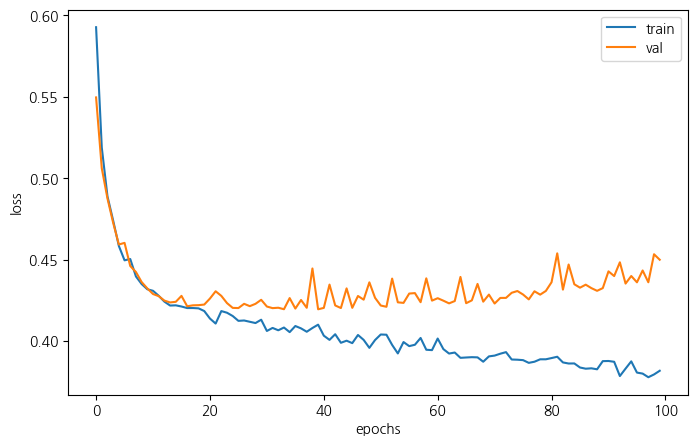

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 모델의 예측 값 출력

In [45]:
pred = model.predict(mms_X_test)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[0.3224107 ],
       [0.16627666],
       [0.13846901],
       [0.13033496],
       [0.07669833],
       [0.54526645],
       [0.1165498 ],
       [0.86403495],
       [0.11942178],
       [0.95446765],
       [0.8548511 ],
       [0.9879759 ],
       [0.38475385],
       [0.32286507],
       [0.84194374],
       [0.8721963 ],
       [0.13846901],
       [0.37331095],
       [0.9401576 ],
       [0.32355034],
       [0.06949241],
       [0.08921746],
       [0.56245553],
       [0.13033496],
       [0.30915934],
       [0.1769368 ],
       [0.97151214],
       [0.3073617 ],
       [0.26667657],
       [0.2872348 ],
       [0.92226344],
       [0.9567568 ],
       [0.13846901],
       [0.8756473 ],
       [0.98629975],
       [0.58309454],
       [0.13846901],
       [0.05862527],
       [0.13846901],
       [0.3281903 ],
       [0.1165498 ],
       [0.9676826 ],
       [0.6592424 ],
       [0.98435545],
       [0.9882578 ],
       [0.17230731],
       [0.56971455],
       [0.282

In [47]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result

,y_test,pred
625,0,0.322411
566,0,0.166277
459,0,0.138469
804,1,0.130335
338,1,0.076698
...,...,...
184,1,0.895998
607,1,0.324866
624,0,0.154422
103,0,0.109423


In [48]:
result['pred'] = result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
result

,y_test,pred
625,0,0
566,0,0
459,0,0
804,1,0
338,1,0
...,...,...
184,1,1
607,1,0
624,0,0
103,0,0


In [49]:
from sklearn.metrics import classification_report
print(classification_report(result['y_test'], result['pred']))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       165
           1       0.75      0.72      0.73       103

    accuracy                           0.80       268
   macro avg       0.79      0.78      0.79       268
weighted avg       0.80      0.80      0.80       268



In [50]:
from sklearn.tree import DecisionTreeClassifier

In [54]:
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc.fit(mms_X_train, y_train)
pred2 = dtc.predict(mms_X_test)
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       165
           1       0.78      0.69      0.73       103

    accuracy                           0.81       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.81      0.80       268



# Functional API를 이용한 함수형 모델
* Sequential API는 단순히 층을 여러 개 쌓는 형태라 복잡한 모델 생성에 한계가 있음.
* Functional  API는 입력층과 출력층을 사용자가 직접 정의 가능
* 다중입력(Multi-input), 다중출력(Multi-output)등 복잡한 모델을 정의 할 수 있음.
* Input(shape=(독립변수 수))로 입력층 정의
* 이전 층을 다음 층의 입력으로 사용
* model()에 입력과 출력을 정의

In [55]:
# tensorflow 2.19버전용
from keras.layers import Input, Dense
from keras.models import Model

In [56]:
# 입력층
inputs = Input(shape=(mms_X_train.shape[1],))

# 은닉층
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# 출력층
outputs = Dense(1, activation='sigmoid')(x)

# 모델 정의
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.4831 - loss: 0.6878 - val_accuracy: 0.6306 - val_loss: 0.6455
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6695 - loss: 0.6236 - val_accuracy: 0.6530 - val_loss: 0.5909
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6657 - loss: 0.5744 - val_accuracy: 0.7351 - val_loss: 0.5469
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7769 - loss: 0.5091 - val_accuracy: 0.7761 - val_loss: 0.5137
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7980 - loss: 0.4821 - val_accuracy: 0.7761 - val_loss: 0.4877
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7851 - loss: 0.4829 - val_accuracy: 0.7985 - val_loss: 0.4732
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8044 - loss: 0.4650 - val_accuracy: 0.7836 - val_loss: 0.4636
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7843 - loss: 0.4739 - val_accuracy: 0.8

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8449 - loss: 0.3886 - val_accuracy: 0.7985 - val_loss: 0.4244
Epoch 52/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8287 - loss: 0.4174 - val_accuracy: 0.8209 - val_loss: 0.4188
Epoch 53/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8239 - loss: 0.4255 - val_accuracy: 0.8209 - val_loss: 0.4209
Epoch 54/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8372 - loss: 0.4013 - val_accuracy: 0.8172 - val_loss: 0.4211
Epoch 55/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8666 - loss: 0.3616 - val_accuracy: 0.7948 - val_loss: 0.4445
Epoch 56/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8292 - loss: 0.3855 - val_accuracy: 0.8209 - val_loss: 0.4212
Epoch 57/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8320 - loss: 0.4297 - val_accuracy: 0.8209 - val_loss: 0.4192
Epoch 58/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8490 - loss: 0.3927 - val_accuracy: 0.8022 - val_

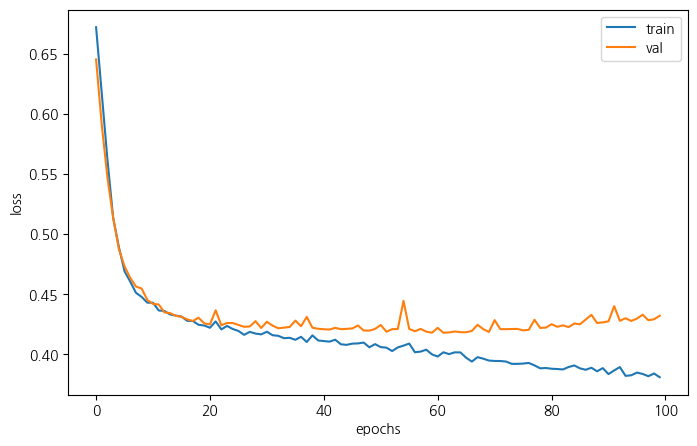

In [57]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100,
                    batch_size=32,
                    validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred)
pred = pred[0].apply(lambda x: 1 if x > 0.5 else 0)
print(classification_report(y_test, pred))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [58]:
class Titanic(Model):
    def __init__(self):
        super(Titanic, self).__init__()
        self.dense1 = Dense(128, activation='relu')
        self.dense2 = Dense(64, activation='relu')
        self.dense3 = Dense(32, activation='relu')
        self.dense4 = Dense(16, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')
    
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.classifier(x)

In [59]:
model = Titanic()
print(model.summary())

Model: "titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/100


2025-05-14 17:01:58.975792: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_193', 12 bytes spill stores, 12 bytes spill loads

2025-05-14 17:01:59.007666: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_193', 4 bytes spill stores, 4 bytes spill loads



20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.6342 - loss: 0.6308 - val_accuracy: 0.6567 - val_loss: 0.5725
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7556 - loss: 0.5179 - val_accuracy: 0.7761 - val_loss: 0.5204
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7973 - loss: 0.5022 - val_accuracy: 0.7799 - val_loss: 0.4835
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8170 - loss: 0.4390 - val_accuracy: 0.7724 - val_loss: 0.4678
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7584 - loss: 0.4894 - val_accuracy: 0.8134 - val_loss: 0.4503
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7774 - loss: 0.4703 - val_accuracy: 0.8209 - val_loss: 0.4666
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8318 - loss: 0.4255 - val_accuracy: 0.7761 - val_loss: 0.4544
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8132 - loss: 0.4359 - val_accuracy: 0.8134 - val_lo

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8502 - loss: 0.3598 - val_accuracy: 0.8172 - val_loss: 0.4421
Epoch 52/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8308 - loss: 0.4023 - val_accuracy: 0.8209 - val_loss: 0.4439
Epoch 53/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8583 - loss: 0.3519 - val_accuracy: 0.7948 - val_loss: 0.4512
Epoch 54/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8318 - loss: 0.3912 - val_accuracy: 0.8097 - val_loss: 0.4512
Epoch 55/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8356 - loss: 0.4151 - val_accuracy: 0.8022 - val_loss: 0.4505
Epoch 56/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8370 - loss: 0.3793 - val_accuracy: 0.7612 - val_loss: 0.5142
Epoch 57/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8433 - loss: 0.4035 - val_accuracy: 0.7948 - val_loss: 0.4501
Epoch 58/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8059 - loss: 0.4141 - val_accuracy: 0.7985 - val_

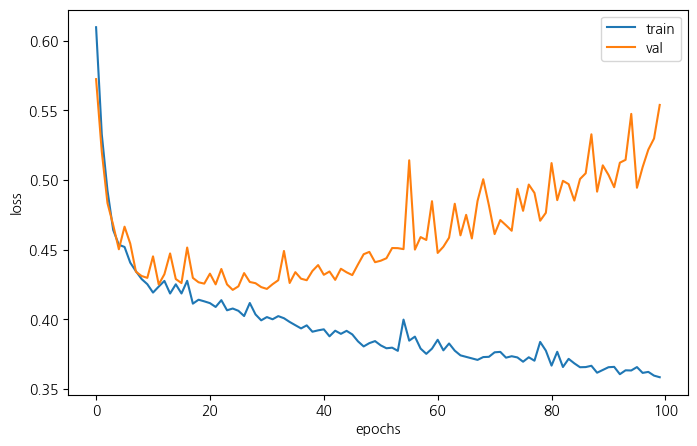

In [60]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, 
                    batch_size=32, validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred)
pred = pred[0].apply(lambda x: 1 if x > 0.5 else 0)
print(classification_report(y_test, pred))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [61]:
print(model.summary())

Model: "titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,333 (138.02 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,556 (92.02 KB)

None
